# AI Assistance Disclosure

This notebook was developed with AI assistance (Claude, Anthropic, Sonnet 4.6).  
AI was used to generate the visualization code (charts and plots).  
The methodology, data inputs, analysis, and result interpretation are the author's own work.  
All generated code was reviewed and verified by the author.

Example prompts used:

- "Generate a bar chart showing the number of grade records per school,
  using anonymized S1–S9 labels for school identifiers"

- "Now generate the same for grade levels"

- "Using the same S1–S9 labels, generate a line chart showing
  Mathematics Target GPA by grade level with a separate line per school"

- "Generate a grouped horizontal bar chart showing the top 10 features
  by average normalized importance score (PredictionValuesChange,
  LossFunctionChange, SHAP) across all prediction scenarios"

- "Generate a bar chart showing final model Test R² scores across three
  prediction scenarios"

- "Also generate a grouped bar chart comparing Test RMSE across all
  models and prediction scenarios."


***Import libraries***

In [2]:
import os
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import numpy as np
from matplotlib.cm import get_cmap


In [3]:
base_path = r"C:\Users\Hande Erdal\Desktop\PREDICTION OF STUDENTS' ACADEMIC PERFORMANCE\results\model_files"
datacsv = r"C:\Users\Hande Erdal\Desktop\PREDICTION OF STUDENTS' ACADEMIC PERFORMANCE\data\students_preprocessed_sentetik.csv"
examplefile = r"C:\Users\Hande Erdal\Desktop\PREDICTION OF STUDENTS' ACADEMIC PERFORMANCE\data\prediction_datasets\30_ongoing_semester.csv"

***Figure 9 Bar chart comparing final model Test R² across all three prediction scenarios***

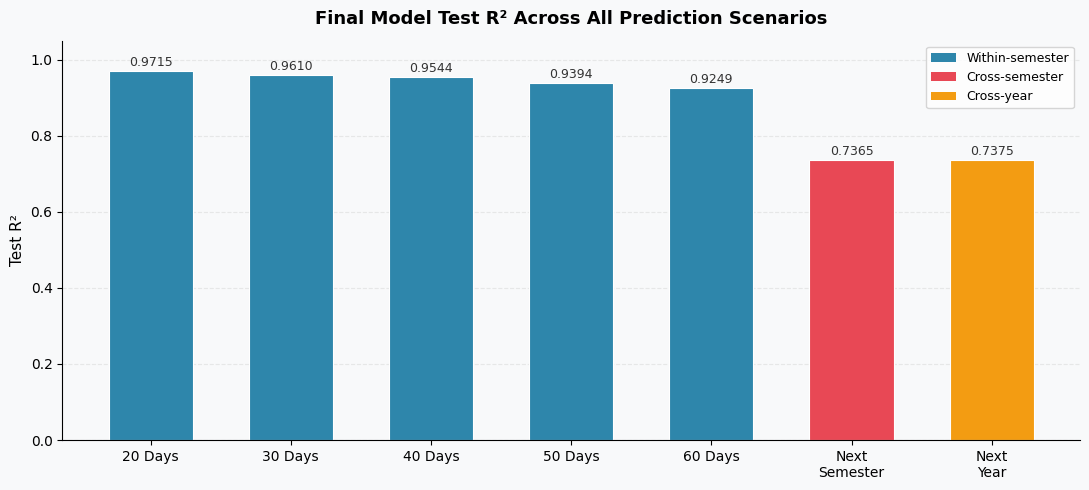

In [5]:

file_map = {
    '20 Days': "results_20_ongoing_semester.json",
    '30 Days': "results_30_ongoing_semester.json",
    '40 Days': "results_40_ongoing_semester.json",
    '50 Days': "results_50_ongoing_semester.json",
    '60 Days': "results_60_ongoing_semester.json",
    'Next\nSemester': "results_next_semester_combined.json",
    'Next\nYear': "results_nextyear.json"
}

scenarios = []
r2_final = []

for label, filename in file_map.items():
    file_path = os.path.join(base_path, filename)
    
    with open(file_path, "r") as f:
        data = json.load(f)
    
    r2 = data["winner_metrics"]["test_r2"]
    
    scenarios.append(label)
    r2_final.append(r2)


colors = ['#2E86AB'] * 5 + ['#E84855', '#F39C12']


fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

bars = ax.bar(scenarios, r2_final, color=colors, edgecolor='white',
              linewidth=0.8, width=0.6)
for bar, val in zip(bars, r2_final):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=9, color='#333333')

ax.set_ylabel('Test R²', fontsize=11)
ax.set_title('Final Model Test R² Across All Prediction Scenarios',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.4, color='#CCCCCC')
ax.set_axisbelow(True)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

legend_elements = [
    Patch(facecolor='#2E86AB', label='Within-semester'),
    Patch(facecolor='#E84855', label='Cross-semester'),
    Patch(facecolor='#F39C12', label='Cross-year')
]
ax.legend(handles=legend_elements, fontsize=9)
save_dir = os.path.join(os.getcwd(), "visualizations")
os.makedirs(save_dir, exist_ok=True)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'final_model_r2.png'), dpi=150, bbox_inches='tight')
plt.show()

***Figure 10 Feature Importance Average Rankings by Metric Across All Prediction Scenarios***

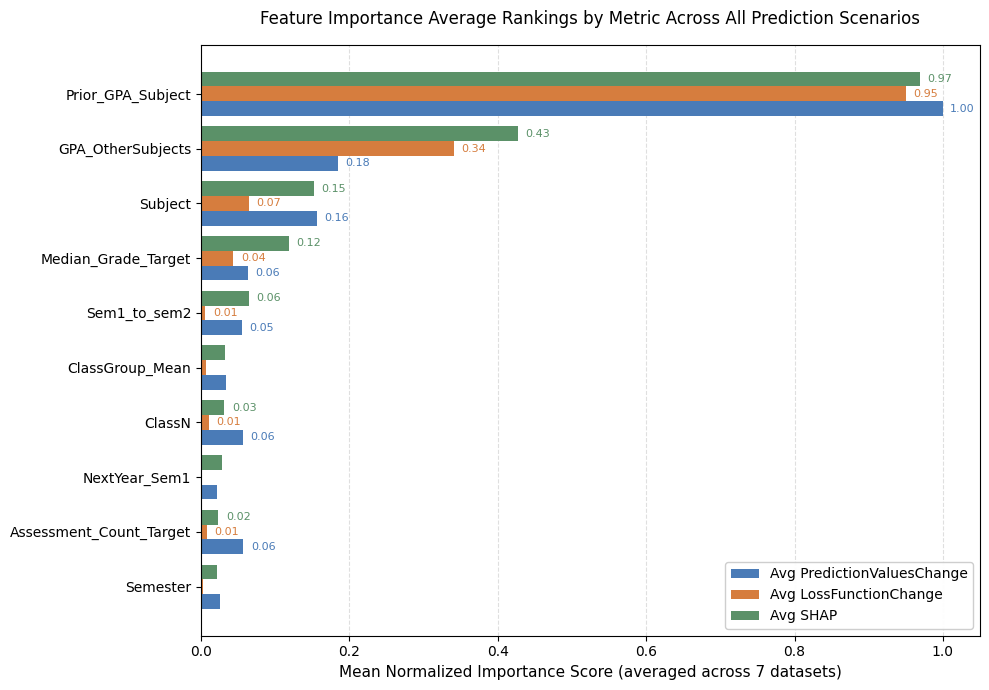

In [6]:
dataset_files = {
    '20-day':         'feature_importance_20_ongoing_semester.csv',
    '30-day':         'feature_importance_30_ongoing_semester.csv',
    '40-day':         'feature_importance_40_ongoing_semester.csv',
    '50-day':         'feature_importance_50_ongoing_semester.csv',
    '60-day':         'feature_importance_60_ongoing_semester.csv',
    'Next Semester':  'feature_importance_next_semester_combined.csv',
    'Next Year':      'feature_importance_nextyear.csv',
}

all_dfs = []
for label, fname in dataset_files.items():
    path = os.path.join(base_path, fname)
    if not os.path.exists(path):
        continue
    df = pd.read_csv(path)
    df['dataset'] = label
    all_dfs.append(df)

combined = pd.concat(all_dfs, ignore_index=True)

agg = combined.groupby('Feature').agg(
    avg_predval=('PredictionValuesChange_norm', 'mean'),
    avg_lossfunc=('LossFunctionChange_norm', 'mean'),
    avg_shap=('SHAP_norm', 'mean'),
).reset_index()

sort_col_map = {
    'shap': 'avg_shap',
    'predval': 'avg_predval',
    'lossfunc': 'avg_lossfunc',
}

top = agg.sort_values(sort_col_map['shap'], ascending=False).head(10)

df_plot = top.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 7))

y_pos = np.arange(len(df_plot))
bar_h = 0.27

ax.barh(y_pos - bar_h, df_plot['avg_predval'],
        height=bar_h, label='Avg PredictionValuesChange', color='#4A7BB7')

ax.barh(y_pos, df_plot['avg_lossfunc'],
        height=bar_h, label='Avg LossFunctionChange', color='#D67D3E')

ax.barh(y_pos + bar_h, df_plot['avg_shap'],
        height=bar_h, label='Avg SHAP', color='#5B9168')

ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot['Feature'], fontsize=10)

ax.set_xlabel('Mean Normalized Importance Score (averaged across 7 datasets)', fontsize=11)
ax.set_xlim(0, 1.05)

ax.set_title('Feature Importance Average Rankings by Metric Across All Prediction Scenarios',
             fontsize=12, pad=15)

ax.legend(loc='lower right', fontsize=10, framealpha=0.95)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
for i in range(len(df_plot)):
    feat = df_plot.iloc[i]

    if max(feat['avg_predval'], feat['avg_lossfunc'], feat['avg_shap']) > 0.05:
        ax.text(feat['avg_predval'] + 0.01, i - bar_h,
                f"{feat['avg_predval']:.2f}", va='center', fontsize=8, color='#4A7BB7')

        ax.text(feat['avg_lossfunc'] + 0.01, i,
                f"{feat['avg_lossfunc']:.2f}", va='center', fontsize=8, color='#D67D3E')

        ax.text(feat['avg_shap'] + 0.01, i + bar_h,
                f"{feat['avg_shap']:.2f}", va='center', fontsize=8, color='#5B9168')

plt.tight_layout()

save_path = os.path.join(save_dir, 'feature_importance.png')
plt.savefig(save_path, dpi=200, bbox_inches='tight')
plt.show()

***Figure 3 Grade Records Distribution Across Schools***

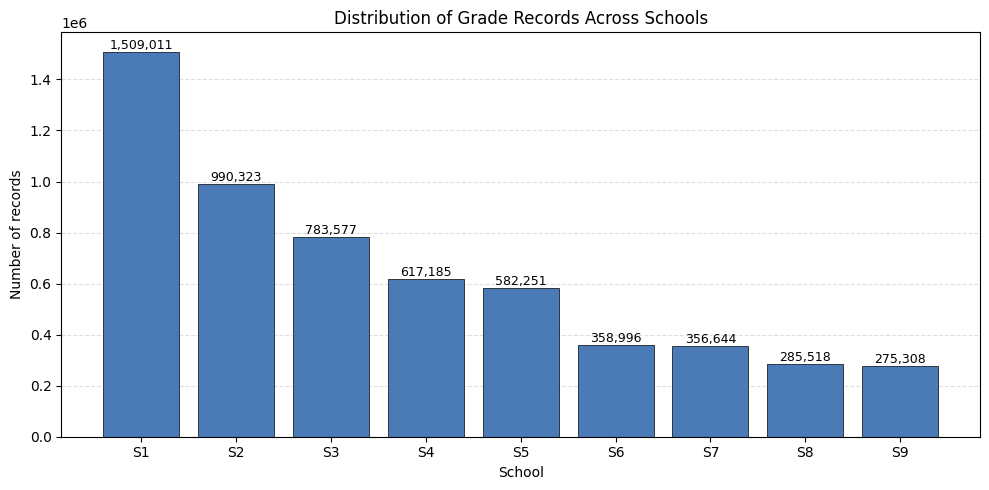

In [7]:
df = pd.read_csv(datacsv)


school_counts = df.groupby('SchoolID').size().reset_index(name='record_count')
school_counts = school_counts.sort_values('record_count', ascending=False).reset_index(drop=True)
school_counts['NewLabel'] = ['S' + str(i + 1) for i in range(len(school_counts))]

per_school = school_counts[['NewLabel', 'record_count']]
per_school.columns = ['SchoolLabel', 'record_count']

df['SchoolLabel'] = df['SchoolID'].map(
    dict(zip(school_counts['SchoolID'], school_counts['NewLabel']))
)


fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(per_school['SchoolLabel'], per_school['record_count'],
              color='#4A7BB7', edgecolor='black', linewidth=0.5)

ax.set_xlabel('School')
ax.set_ylabel('Number of records')
ax.set_title('Distribution of Grade Records Across Schools')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

for bar, count in zip(bars, per_school['record_count']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{int(count):,}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'figure_records_per_school.png'), dpi=200, bbox_inches='tight')
plt.show()



***Figure 4 Grade Records Distribution Across Grade Levels***

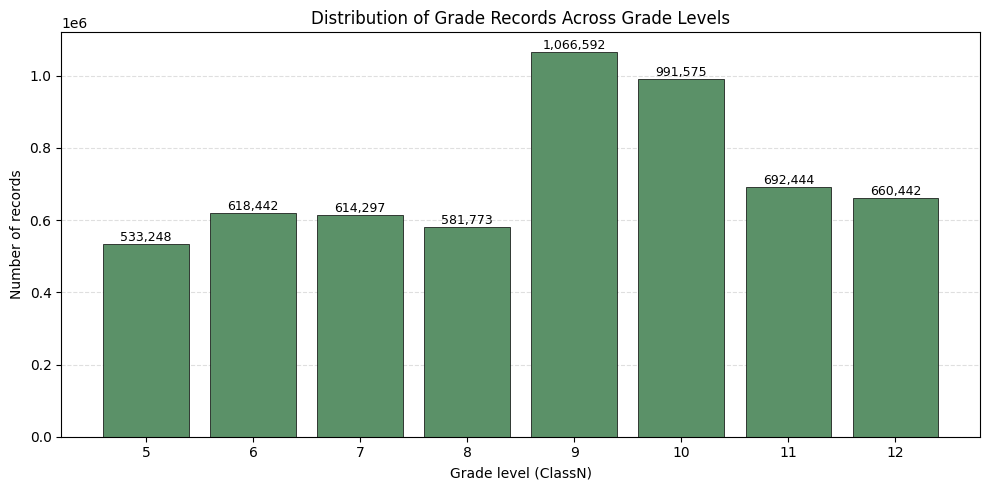

In [8]:
per_grade = df.groupby('ClassN').size().reset_index(name='record_count')
per_grade = per_grade.sort_values('ClassN')

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(per_grade['ClassN'].astype(str),
              per_grade['record_count'],
              color='#5B9168', edgecolor='black', linewidth=0.5)

ax.set_xlabel('Grade level (ClassN)')
ax.set_ylabel('Number of records')
ax.set_title('Distribution of Grade Records Across Grade Levels')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

for bar, count in zip(bars, per_grade['record_count']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{int(count):,}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'figure_records_per_grade.png'), dpi=200, bbox_inches='tight')
plt.show()

***Figure 7 Average Mathematics Target GPA by Grade Level Across Schools***

C:\Users\Hande Erdal\AppData\Local\Temp\ipykernel_12980\1313080143.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab10')


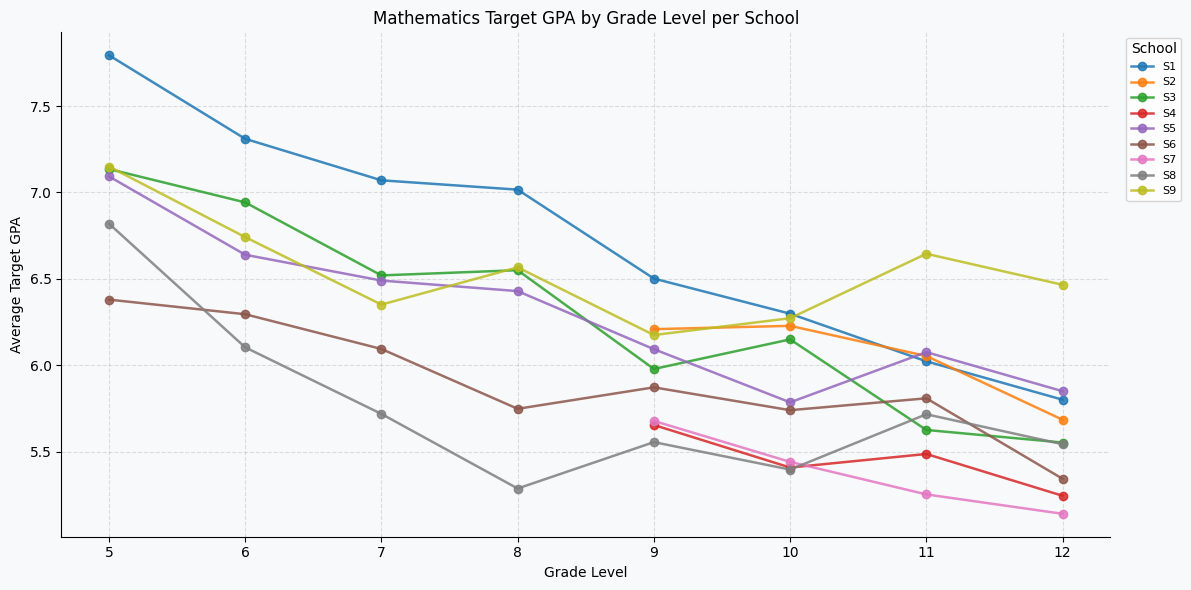

In [10]:
df_30days = pd.read_csv(examplefile)


school_counts = df_30days.groupby('SchoolID').size().reset_index(name='record_count')
school_counts = school_counts.sort_values('record_count', ascending=False).reset_index(drop=True)
school_counts['NewLabel'] = ['S' + str(i + 1) for i in range(len(school_counts))]

df_30days['SchoolLabel'] = df_30days['SchoolID'].map(
    dict(zip(school_counts['SchoolID'], school_counts['NewLabel']))
)

math_data = df_30days[df_30days['Subject'] == 'Mathematics'].copy()
math_data = math_data.dropna(subset=['SchoolLabel'])

school_class_avg = (
    math_data.groupby(['SchoolLabel', 'ClassN'])['Target_GPA']
    .mean()
    .reset_index()
)

school_order = school_counts['NewLabel'].tolist()

cmap = get_cmap('tab10')
color_map = {label: cmap(i / max(len(school_order), 1)) for i, label in enumerate(school_order)}


fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

for label in school_order:
    data = school_class_avg[school_class_avg['SchoolLabel'] == label].sort_values('ClassN')
    if len(data) == 0:
        continue

    ax.plot(
        data['ClassN'],
        data['Target_GPA'],
        marker='o',
        linewidth=1.8,
        markersize=6,
        color=color_map[label],
        label=label,
        alpha=0.85
    )

ax.set_xlabel('Grade Level')
ax.set_ylabel('Average Target GPA')
ax.set_title('Mathematics Target GPA by Grade Level per School')

ax.set_xticks(sorted(math_data['ClassN'].unique()))

ax.legend(title='School', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

ax.grid(linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'figure_math_gpa_by_school.png'), dpi=200, bbox_inches='tight')
plt.show()

***Figure 1 Distribution of Graded Records Across Compulsory Subjects in the Lithuanian Basic Education Curriculum***

In [11]:

compulsory_subjects = [
    'Moral Education (Religion)',
    'Moral Education (Ethics)',
    'English Language',
    'Lithuanian Language',
    'Mathematics',
    'History',
    'Geography',
    'Physics',
    'Chemistry',
    'Biology',
    'Art',
    'Information Technology',
    'Physical Education'
]

state_level_subjects = [
    'Lithuanian Language',
    'Mathematics',
    'Biology',
    'Chemistry',
    'Physics',
    'History',
    'Geography',
    'Information Technology',
    'English Language',
]

C:\Users\Hande Erdal\AppData\Local\Temp\ipykernel_12980\768816592.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ].groupby('Subject').apply(lambda x: x.groupby('StudentID')['Grade'].count().mean()).sort_values(ascending=False)


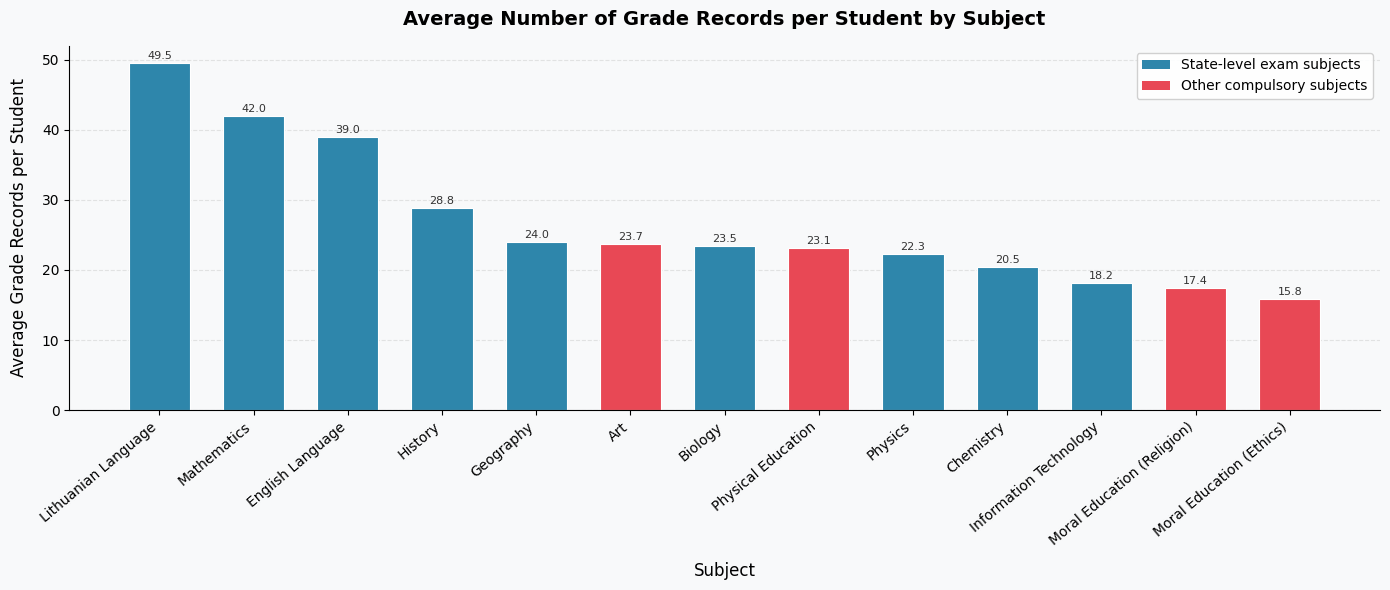

In [12]:
subject_student_avg = df[
    df['Subject'].isin(compulsory_subjects) &
    df['Grade'].notna() &
    (df['Grade'] != 0)
].groupby('Subject').apply(lambda x: x.groupby('StudentID')['Grade'].count().mean()).sort_values(ascending=False)

colors = ['#2E86AB' if subj in state_level_subjects else '#E84855' for subj in subject_student_avg.index]

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

bars = ax.bar(subject_student_avg.index, subject_student_avg.values, color=colors,
              edgecolor='white', linewidth=0.8, width=0.65)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height + 0.3,
            f'{height:.1f}', ha='center', va='bottom', fontsize=8, color='#333333')

ax.set_xticks(range(len(subject_student_avg.index)))
ax.set_xticklabels(subject_student_avg.index, rotation=40, ha='right', fontsize=10)
ax.set_xlabel('Subject', fontsize=12, labelpad=10)
ax.set_ylabel('Average Grade Records per Student', fontsize=12, labelpad=10)
ax.set_title('Average Number of Grade Records per Student by Subject', fontsize=14, fontweight='bold', pad=15)

ax.grid(axis='y', linestyle='--', alpha=0.5, color='#CCCCCC')
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

legend_elements = [
    Patch(facecolor='#2E86AB', label='State-level exam subjects'),
    Patch(facecolor='#E84855', label='Other compulsory subjects')
]
ax.legend(handles=legend_elements, fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'subject_student_avg.png'), dpi=200, bbox_inches='tight')
plt.show()

***Figure 2 Grade Distribution Across Target Subjects***

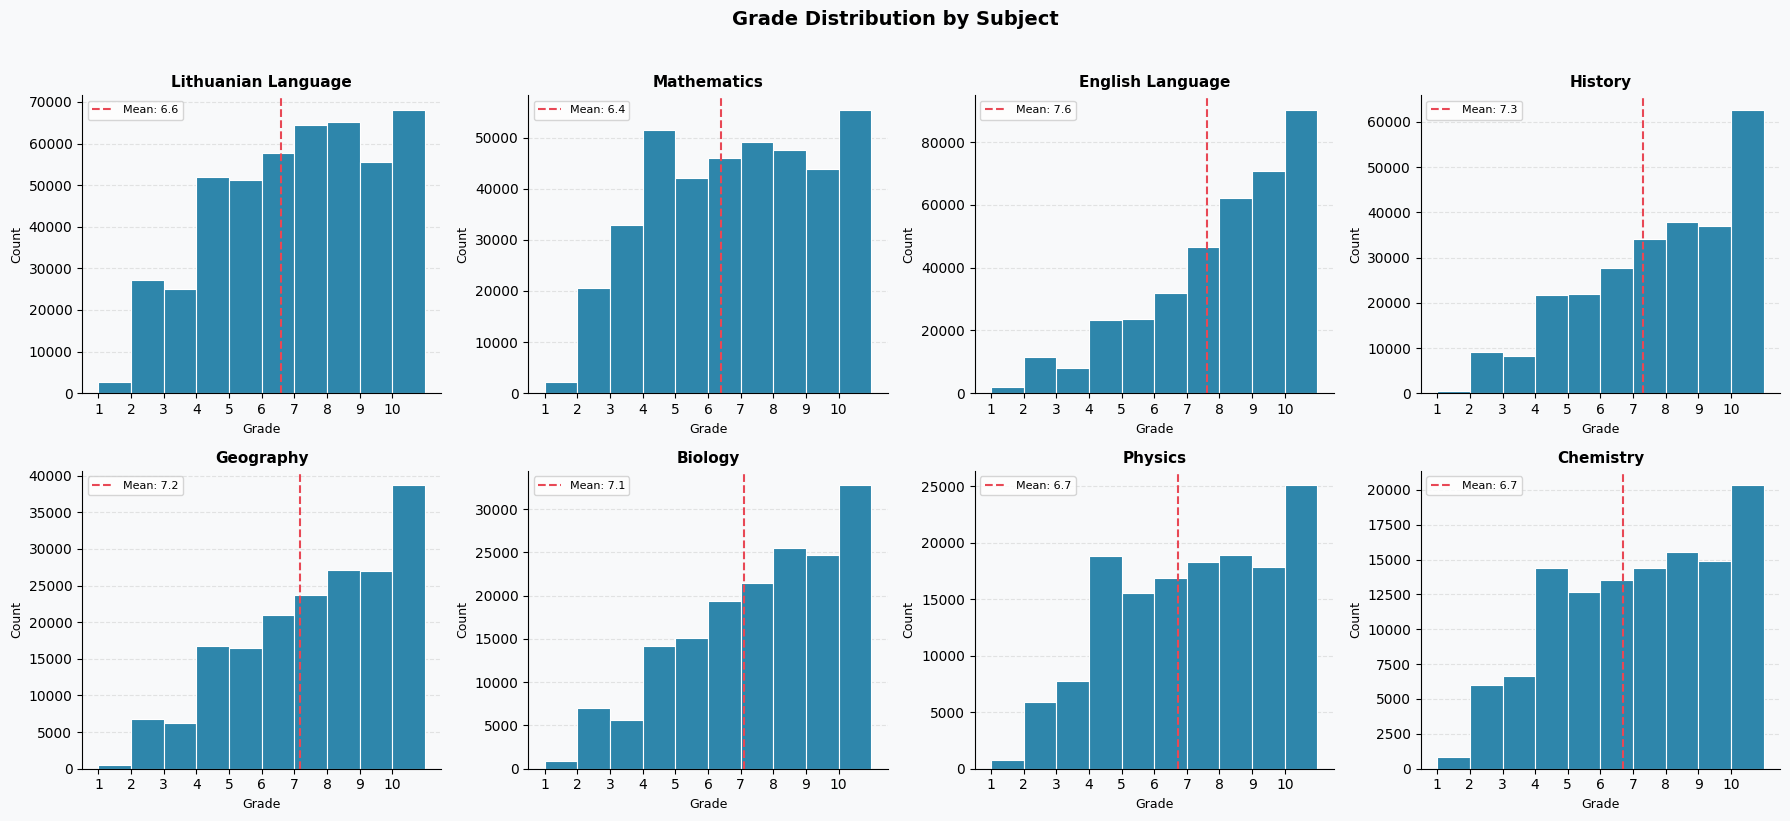

In [13]:

target_subjects = [
    'Lithuanian Language',
    'Mathematics',
    'English Language',
    'History',
    'Geography',
    'Biology',
    'Physics',
    'Chemistry'
]

target_data = df[
    df['Subject'].isin(target_subjects) &
    df['Grade'].notna() &
    (df['Grade'] != 0)
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.patch.set_facecolor('#F8F9FA')
axes = axes.flatten()

for i, subj in enumerate(target_subjects):
    ax = axes[i]
    ax.set_facecolor('#F8F9FA')
    data = target_data[target_data['Subject'] == subj]['Grade']
    
    ax.hist(data, bins=10, range=(1, 11), color='#2E86AB', edgecolor='white', linewidth=0.8)
    ax.set_title(subj, fontsize=11, fontweight='bold')
    ax.set_xlabel('Grade', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_xticks(range(1, 11))
    ax.grid(axis='y', linestyle='--', alpha=0.5, color='#CCCCCC')
    ax.set_axisbelow(True)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    
    mean = data.mean()
    ax.axvline(mean, color='#E84855', linestyle='--', linewidth=1.5, label=f'Mean: {mean:.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Grade Distribution by Subject', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'grade_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

***Figure 5 Grade Distribution Across Target Subjects***

In [15]:
df_30days['Total_Passed_Assessments']=df_30days['Total_Passed_Assessments'].fillna(0)
df_30days['Total_Failed_Assessments']=df_30days['Total_Failed_Assessments'].fillna(0)
missing =   df_30days.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len( df_30days  ) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

                         Missing Count  Missing %
Grade_Trend_Slope                 4782       1.77
Grade_Trend_Intercept             4782       1.77
GPA_OtherSubjects                   41       0.02
Assessment_Count_Others             26       0.01


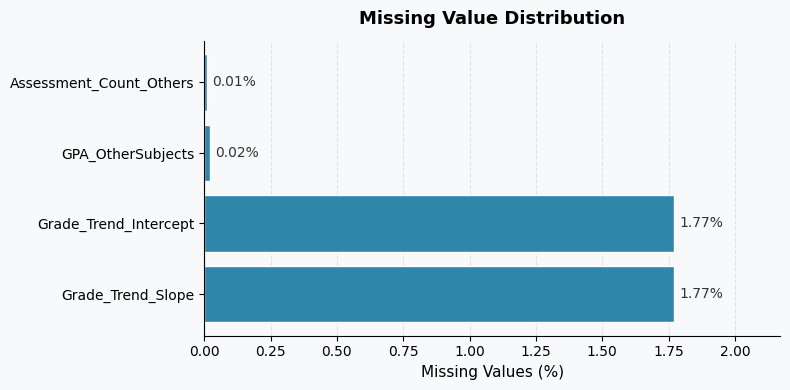

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

bars = ax.barh(missing_df.index, missing_df['Missing %'], color='#2E86AB', edgecolor='white')

for bar, val in zip(bars, missing_df['Missing %']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10, color='#333333')

ax.set_xlabel('Missing Values (%)', fontsize=11)
ax.set_title('Missing Value Distribution', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, missing_df['Missing %'].max() + 0.4)
ax.grid(axis='x', linestyle='--', alpha=0.5, color='#CCCCCC')
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'missing_data.png'), dpi=150, bbox_inches='tight')

plt.show()

***Figure 6 Target GPA Distribution and Outliers Across Target Subjects***

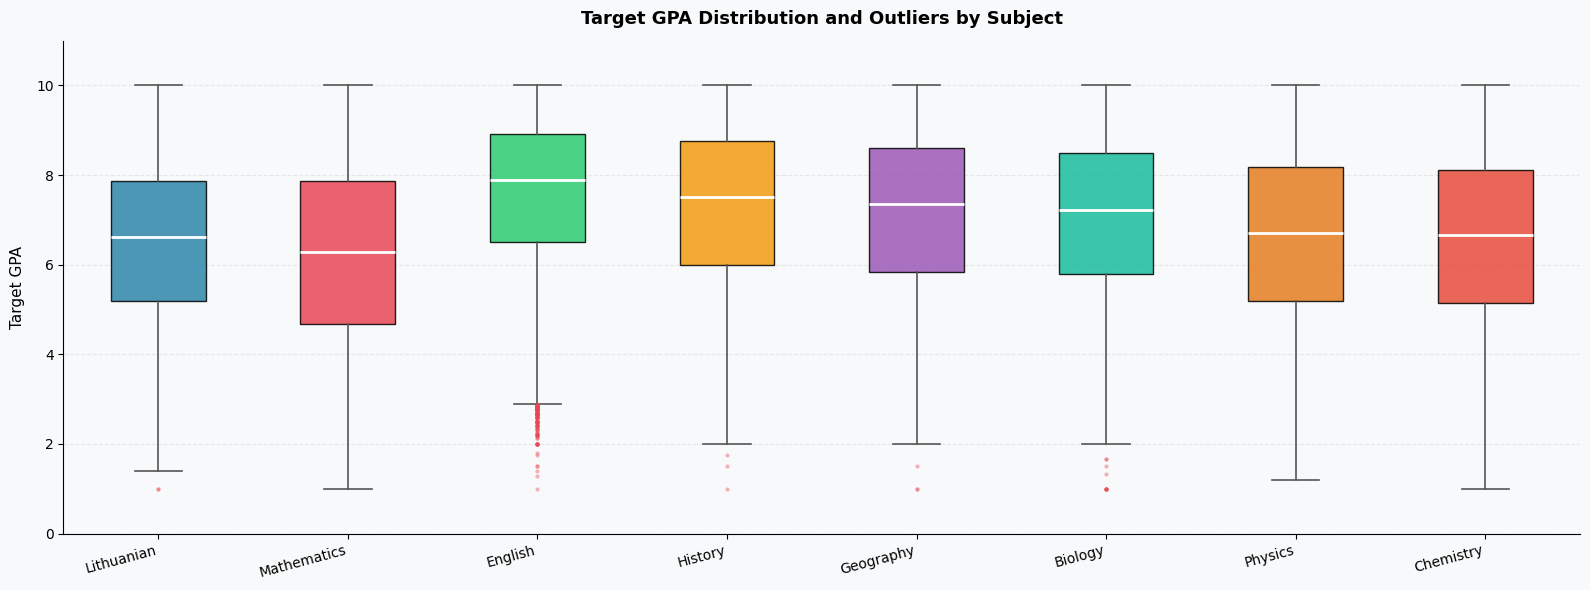

In [32]:
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

plot_data = []
for subj in target_subjects:
    subj_data = df_30days[df_30days['Subject'] == subj]['Mean_SUBJECT_Target'].dropna()
    plot_data.append(subj_data)

short_names = ['Lithuanian', 'Mathematics', 'English', 'History',
               'Geography', 'Biology', 'Physics', 'Chemistry']

bp = ax.boxplot(plot_data,
                patch_artist=True,
                widths=0.5,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='#555555', linewidth=1.2),
                capprops=dict(color='#555555', linewidth=1.2),
                flierprops=dict(marker='o', markerfacecolor='#E84855',
                               markersize=3, alpha=0.4, markeredgewidth=0))

colors = ['#2E86AB', '#E84855', '#2ECC71', '#F39C12',
          '#9B59B6', '#1ABC9C', '#E67E22', '#E74C3C']


for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_xticks(range(1, len(target_subjects) + 1))
ax.set_xticklabels(short_names, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Target GPA', fontsize=11, labelpad=8)
ax.set_title('Target GPA Distribution and Outliers by Subject',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, 11)
ax.grid(axis='y', linestyle='--', alpha=0.4, color='#CCCCCC')
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'target_boxplot.png'), dpi=150, bbox_inches='tight')

plt.show()

***Figure 8 Baseline Model Comparison by Test RMSE Across Prediction Scenarios***

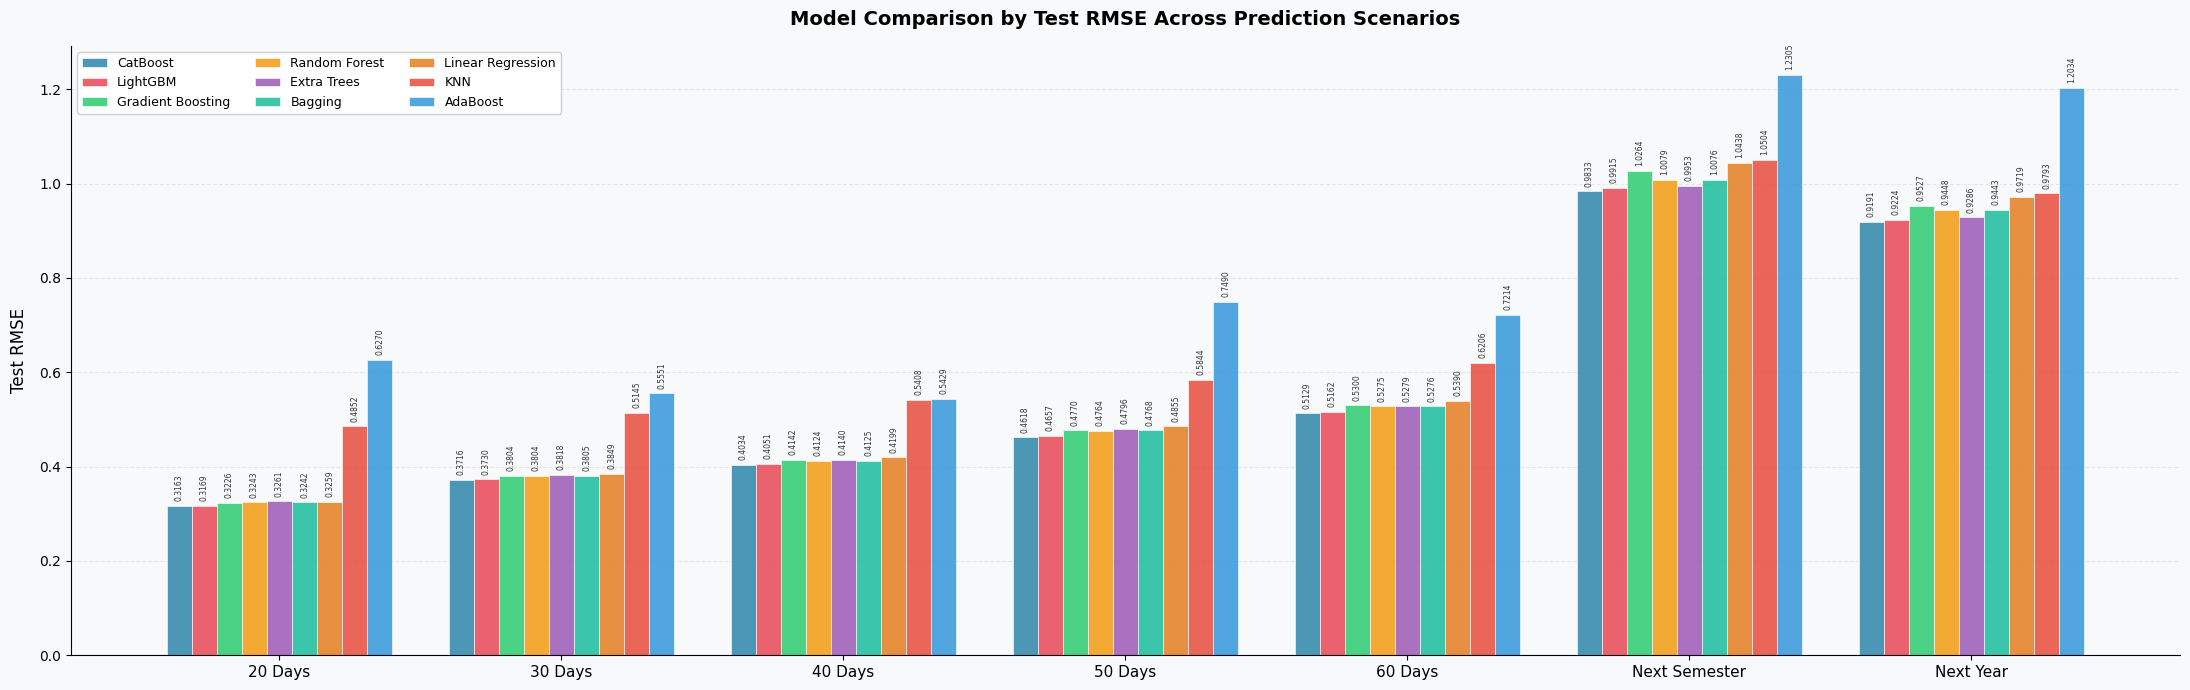

In [ ]:
with open(r"C:\Users\Hande Erdal\Desktop\PREDICTION OF STUDENTS' ACADEMIC PERFORMANCE\results\base_training_results\all_base_results.json", 'r') as f:
    data = json.load(f)

datasets = ['20_ongoing_semester', '30_ongoing_semester', '40_ongoing_semester',
            '50_ongoing_semester', '60_ongoing_semester', 'next_semester_combined', 'nextyear']

dataset_labels = ['20 Days', '30 Days', '40 Days', '50 Days', '60 Days', 'Next Semester', 'Next Year']

models = ['CatBoost', 'LightGBM', 'Gradient Boosting', 'Random Forest',
          'Extra Trees', 'Bagging', 'Linear Regression', 'KNN', 'AdaBoost']

colors = ['#2E86AB', '#E84855', '#2ECC71', '#F39C12', '#9B59B6',
          '#1ABC9C', '#E67E22', '#E74C3C', '#3498DB']

n_datasets = len(datasets)
n_models = len(models)
group_width = 0.8
bar_width = group_width / n_models
x = np.arange(n_datasets)

fig, ax = plt.subplots(figsize=(22, 7))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

for j, (model, color) in enumerate(zip(models, colors)):
    rmse_values = []
    for dataset in datasets:
        try:
            rmse = data[dataset]['all_models'][model]['test_rmse']
        except KeyError:
            rmse = 0
        rmse_values.append(rmse)
    
    offset = (j - n_models / 2 + 0.5) * bar_width
    bars = ax.bar(x + offset, rmse_values, bar_width,
                  label=model, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
    
    for bar, val in zip(bars, rmse_values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{val:.4f}', ha='center', va='bottom',
                    fontsize=5.5, rotation=90, color='#333333')

ax.set_xticks(x)
ax.set_xticklabels(dataset_labels, fontsize=11)
ax.set_ylabel('Test RMSE', fontsize=12, labelpad=8)
ax.set_title('Model Comparison by Test RMSE Across Prediction Scenarios',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=9, ncol=3, framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.4, color='#CCCCCC')
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'model_comparison_rmse.png'), dpi=150, bbox_inches='tight')
plt.show()